<a href="https://colab.research.google.com/github/Leonardo-Leal-Salazar/Probabilidad1/blob/main/Unidad3/Practica7_U3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unidad 3
## Programa 7: Ejercicio 2
### Falicitador: Jose Gabriel Rodriguez Rivas
### Alumno: Erik Leonardo Leal Salazar 🌇 🦊 🍂

En una tómbola se colocan boletos con los siguientes premios:
Premio (X): A, B, C, D
Monto (pesos):0, 10, 20, 50
Probabilidad P(X): 0.50, 0.30, 0.15, 0.05

1. Verifique que las probabilidades sumen 1.
2. Elabore la distribución de probabilidad de 𝑿.
3. Calcule:
• El valor esperado 𝑬 𝑿 (ganancia promedio esperada).
• La varianza y la desviación estándar.
4. Construya la función de distribución acumulada 𝑭 𝒙 y represéntela gráficamente.
5. Interprete los resultados:
• ¿Qué significa el valor esperado en este contexto?
• ¿El juego es favorable para el jugador?

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [1]:
# ============================================================
# PUNTO 1: Verificar que las probabilidades sumen 1
# ============================================================

x = [0, 10, 20, 50]        # Monto en pesos de cada premio
p = [0.50, 0.30, 0.15, 0.05]  # Probabilidad de cada premio

suma = sum(p)
print("Verificación de la distribución de probabilidad:")
print(f"  Suma de todas las probabilidades P(X) = {suma}")

if round(suma, 10) == 1:
    print("  ✓ La distribución es válida: las probabilidades suman 1.")
else:
    print("  ✗ Error: las probabilidades NO suman 1.")

Verificación de la distribución de probabilidad:
  Suma de todas las probabilidades P(X) = 1.0
  ✓ La distribución es válida: las probabilidades suman 1.


Distribución de Probabilidad de X:
Premio     Monto (X)       P(X)      
-----------------------------------
A          $0              0.50      
B          $10             0.30      
C          $20             0.15      
D          $50             0.05      


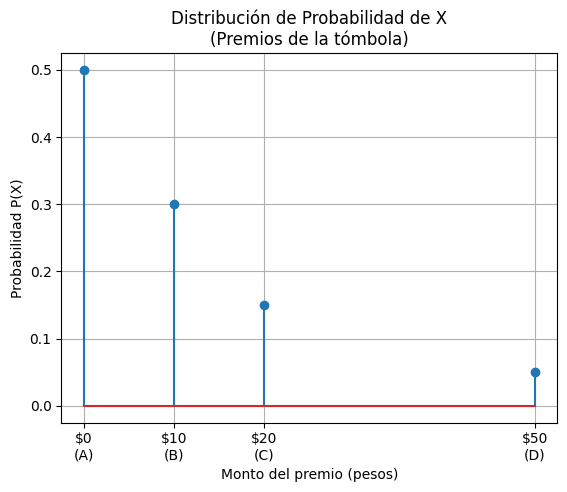

In [3]:
# ============================================================
# PUNTO 2: Distribución de probabilidad de X
# ============================================================

premios = ['A', 'B', 'C', 'D']  # Etiquetas de los premios

# Mostrar tabla de distribución
print("Distribución de Probabilidad de X:")
print(f"{'Premio':<10} {'Monto (X)':<15} {'P(X)':<10}")
print("-" * 35)
for premio, xi, pi in zip(premios, x, p):
    print(f"{premio:<10} ${xi:<14} {pi:<10.2f}")

# Graficar distribución
plt.stem(x, p)
plt.title("Distribución de Probabilidad de X\n(Premios de la tómbola)")
plt.xlabel("Monto del premio (pesos)")
plt.ylabel("Probabilidad P(X)")
plt.xticks(x, [f"${xi}\n({pr})" for xi, pr in zip(x, premios)])
plt.grid(True)
plt.show()

In [4]:
# ============================================================
# PUNTO 3: Valor esperado, varianza y desviación estándar
# ============================================================

# --- Valor esperado E(X) ---
valor_esperado = 0
print("Cálculo del Valor Esperado E(X):")
print(f"{'Monto (X)':<12} {'P(X)':<10} {'X·P(X)':<10}")
print("-" * 32)

for xi, pi in zip(x, p):
    producto = xi * pi
    valor_esperado += producto
    print(f"${xi:<11} {pi:<10.2f} {producto:<10.2f}")

print(f"\n  E(X) = ${valor_esperado:.2f} pesos")

# --- Varianza Var(X) ---
e_x2 = 0
print("\nCálculo de la Varianza Var(X):")
print(f"{'Monto (X)':<12} {'P(X)':<10} {'X²·P(X)':<10}")
print("-" * 32)

for xi, pi in zip(x, p):
    producto2 = xi**2 * pi
    e_x2 += producto2
    print(f"${xi:<11} {pi:<10.2f} {producto2:<10.2f}")

varianza = e_x2 - valor_esperado**2
desviacion_std = math.sqrt(varianza)

print(f"\n  E(X²)                     = {e_x2:.4f}")
print(f"  Var(X) = E(X²) - [E(X)]² = {e_x2:.4f} - {valor_esperado:.4f}² = {varianza:.4f}")
print(f"  Desviación estándar σ = √{varianza:.4f} = {desviacion_std:.4f} pesos")

Cálculo del Valor Esperado E(X):
Monto (X)    P(X)       X·P(X)    
--------------------------------
$0           0.50       0.00      
$10          0.30       3.00      
$20          0.15       3.00      
$50          0.05       2.50      

  E(X) = $8.50 pesos

Cálculo de la Varianza Var(X):
Monto (X)    P(X)       X²·P(X)   
--------------------------------
$0           0.50       0.00      
$10          0.30       30.00     
$20          0.15       60.00     
$50          0.05       125.00    

  E(X²)                     = 215.0000
  Var(X) = E(X²) - [E(X)]² = 215.0000 - 8.5000² = 142.7500
  Desviación estándar σ = √142.7500 = 11.9478 pesos


Función de Distribución Acumulada F(x):
Premio     Monto (X)       P(X)       F(X)      
---------------------------------------------
A          $0              0.50       0.50      
B          $10             0.30       0.80      
C          $20             0.15       0.95      
D          $50             0.05       1.00      


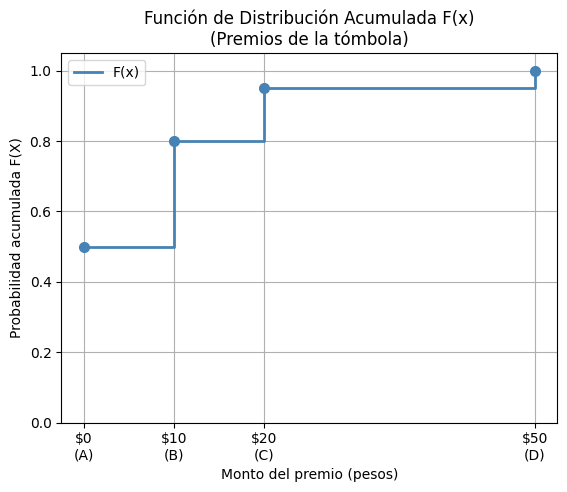

In [5]:
# ============================================================
# PUNTO 4: Función de Distribución Acumulada F(x)
# ============================================================

# Calcular FDA
F = np.cumsum(p)

# Mostrar tabla
print("Función de Distribución Acumulada F(x):")
print(f"{'Premio':<10} {'Monto (X)':<15} {'P(X)':<10} {'F(X)':<10}")
print("-" * 45)
for premio, xi, pi, fi in zip(premios, x, p, F):
    print(f"{premio:<10} ${xi:<14} {pi:<10.2f} {fi:<10.2f}")

# Graficar
plt.step(x, F, where='post', color='steelblue', linewidth=2, label='F(x)')
plt.plot(x, F, 'o', color='steelblue', markersize=7)
plt.title("Función de Distribución Acumulada F(x)\n(Premios de la tómbola)")
plt.xlabel("Monto del premio (pesos)")
plt.ylabel("Probabilidad acumulada F(X)")
plt.xticks(x, [f"${xi}\n({pr})" for xi, pr in zip(x, premios)])
plt.grid(True)
plt.ylim(0, 1.05)
plt.legend()
plt.show()

# 5.- Interprete los resultados:
## • ¿Qué significa el valor esperado en este contexto?
`El valor esperado es E(X) = $8.50 pesos por boleto, esto significa que si un jugador participara en la tombola muchas veces, en promedio ganaria $8.50 pesos por cada boleto. Es importante entender que esto es un promedio teórico, no una ganancia garantizada en cada jugada.`

## • ¿El juego es favorable para el jugador?


```
La respuesta depende del precio del boleto, que el ejercicio no especifica, por lo que hay tres escenarios posibles:

 Si el boleto cuesta menos de $8.50 → el juego es favorable para el jugador, ya que en promedio ganaría más de lo que paga.
 Si el boleto cuesta más de $8.50 → el juego es favorable para la tómbola, ya que el jugador pagará más de lo que espera recuperar.
 Si el boleto cuesta exactamente $8.50 → el juego es justo, ninguna de las dos partes tiene ventaja.

Vale la pena mencionar también que la desviación estándar es σ = $11.69, con un coeficiente de variación del 137.5%, lo que indica una variabilidad muy alta. Esto refleja que las ganancias son muy desiguales: la mayoría de los jugadores no ganará nada o ganará poco, mientras que muy pocos obtendrán el premio mayor de $50.
```

